In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# -------------------------
# Load CRIX data from CSV
# -------------------------

EVENT_DATES = [
    '2017-10-16', '2019-02-28', '2019-12-08', '2020-01-02', '2020-10-14',
    '2020-12-01', '2021-04-15', '2021-08-05', '2021-10-27', '2021-12-09',
    '2022-06-30', '2022-09-06', '2022-09-15', '2024-03-13',
]

crix_df = pd.read_csv(
    "../Data/crix_df.csv",
    index_col=0,
    parse_dates=True,
)

# Ensure DatetimeIndex
crix_df.index = pd.to_datetime(crix_df.index)

In [7]:
import statsmodels.api as sm

def run_market_model(crix_df, x_col='crix_return', y_col='eth_return'):
    """
    Fit a single-factor market model (ETH return regressed on CRIX return),
    clean NaN/inf values first, and compute abnormal returns (AR).
    """
    df = crix_df.copy()

    if df[[x_col, y_col]].isnull().values.any():
        print("NaN values found. Dropping NaNs.")
        df = df.dropna(subset=[x_col, y_col])

    if np.isinf(df[[x_col, y_col]].values).any():
        print("Infinite values found. Dropping infinities.")
        df = df[np.isfinite(df[x_col]) & np.isfinite(df[y_col])]

    if df[x_col].nunique() == 1 or df[y_col].nunique() == 1:
        raise ValueError("One of the columns has constant values, which will cause issues in regression.")

    X = sm.add_constant(df[x_col].values.reshape(-1, 1))
    y = df[y_col].values.reshape(-1, 1)
    results = sm.OLS(y, X).fit()
    alpha, beta = results.params
    print("Alpha, Beta:", alpha, beta)

    df['e_return'] = alpha + beta * df[x_col]
    df['AR'] = df[y_col] - df['e_return']
    return df, alpha, beta, results


def plot_return_and_ar(df, event_dates, save_path=None):
    """
    Two-panel chart: raw ETH log return on top, cumulative-style
    abnormal return ratio on bottom, with event date markers.
    """
    plt.rcParams['font.family'] = 'serif'

    fig, axes = plt.subplots(2, 1, figsize=(20, 12), sharex=True, gridspec_kw={'hspace': 0.05})

    axes[0].plot(df.index, df['eth_return'], color='black', linewidth=2)
    axes[0].set_ylabel('Log return', fontsize=16)

    ar_ratio = np.exp(df['AR']) / np.exp(df['AR'].min())
    axes[1].plot(df.index, ar_ratio, color='blue', linewidth=2)
    axes[1].set_ylabel(r'$\exp(AR_t)\ /\ \exp(AR^{min})$', fontsize=16)

    for ax in axes:
        for d in event_dates:
            ax.axvline(pd.to_datetime(d), color='#7f7f7f', linestyle=':', linewidth=0.5)
        ax.set_facecolor('none')
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('black')
            spine.set_linewidth(1)
        ax.tick_params(axis='both', labelsize=14)

    axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

    fig.patch.set_alpha(0)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=200, transparent=True)

    plt.show()
    return fig

Alpha, Beta: 0.0004796470152880316 0.44525528694219385


/var/folders/jp/bd398j317bgfry9k1hrttp6h0000gn/T/ipykernel_4468/3208017859.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


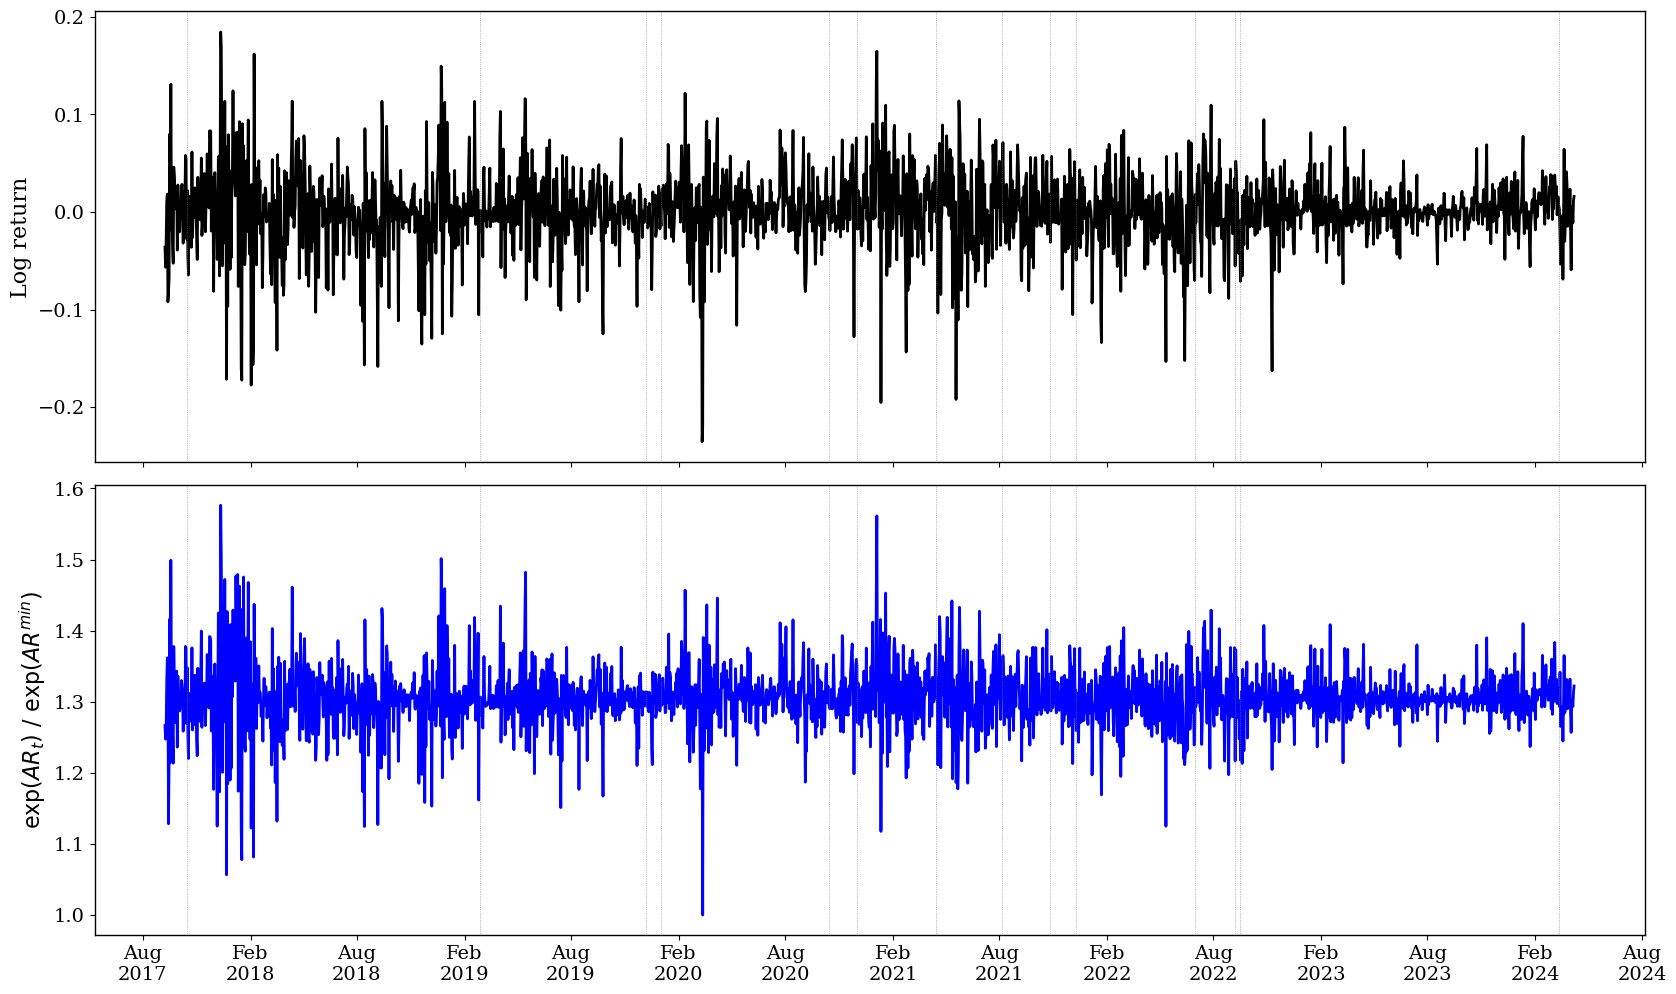

In [8]:
crix_df, alpha, beta, ols_results = run_market_model(crix_df)
fig = plot_return_and_ar(crix_df, EVENT_DATES, save_path="indicator_ts.png")